In [585]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import numpy.ma as ma

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [3]:
%load_ext autoreload
%autoreload 2

In [167]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):
    
    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

In [381]:
def zoom_qpos(zoom):

    sub_ids = zoom.sub['IDMostbound'][zoom.fof['halo_firstsub']]

    w_dm        = np.isin(zoom.dm['ids'], sub_ids)
    w_gas       = np.isin(zoom.gas['ids'], sub_ids)
    w_stars     = np.isin(zoom.stars['ids'], sub_ids)
    w_bh        = np.isin(zoom.bh['ids'], sub_ids)

    pos_gas       = zoom.gas['pos'][w_gas]
    pos_stars     = zoom.stars['pos'][w_stars]
    pos_bh        = zoom.bh['pos'][w_bh]

    #gas
    X1 = zoom.dm['pos']
    X2 = pos_gas

    kdt = KDTree(X1, boxsize=500.0+1e-9)
    dist_gas, ind_gas = kdt.query(X2, k=1)

    #stars
    X2 = pos_stars
    dist_stars, ind_stars = kdt.query(X2, k=1)

    #bh
    X2 = pos_bh
    dist_bh, ind_bh = kdt.query(X2, k=1)

    mbIDs = np.copy(sub_ids)

    ids_dm = zoom.dm['ids']

    mbIDs[np.isin(sub_ids, zoom.gas['ids'])]       = ids_dm[ind_gas]
    mbIDs[np.isin(sub_ids, zoom.stars['ids'])]     = ids_dm[ind_stars]
    mbIDs[np.isin(sub_ids, zoom.bh['ids'])]        = ids_dm[ind_bh]

    mbIDs = mbIDs.astype('uint64')   

    ids_dm_ics = np.concatenate((zoom_ics.dm['ids'], zoom_ics.lowres_dm['ids']))
    pos_dm_ics = np.vstack((zoom_ics.dm['pos'], zoom_ics.lowres_dm['pos']))

    sort_ics_dm = np.argsort(ids_dm_ics)

    pos_ics = pos_dm_ics[sort_ics_dm][mbIDs-1]

    return pos_ics

In [357]:
base_ics = "/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/"
zoom_ics = bacco.Simulation(basedir=base_ics, halo_file="groups_000/fof_subhalo_tab_000", dm_file="snapdir_000/snapshot_ics_000", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                    tau=tau, ns=ns, sigma8=sigma8, use_ids=True)

2024-08-30 16:36:40,562 bacco.sims : Initialising simulation Default
2024-08-30 16:36:40,563 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000
2024-08-30 16:36:40,573 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000
2024-08-30 16:36:40,577 bacco.sims : ...done in 0.0156 s


### Load the Zoom

In [56]:
base = "/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/"
base_dm = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/1pmbin_2160/gro_output"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), numpart=4320**3, use_ids=True)

print(zoom.header['Redshift'])

2024-08-30 11:55:34,409 bacco.sims : Initialising simulation Default
2024-08-30 11:55:34,411 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-08-30 11:55:34,414 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-08-30 11:55:34,419 bacco.sims : ...done in 0.00952 s


4.440892098500626e-16


### Zoom Lagrangian positions

In [382]:
lag_pos_zoom = zoom_qpos(zoom)

### Load the Original Sim

In [162]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=snap)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2024-08-30 15:14:17,638 bacco.sims : Initialising simulation Default
2024-08-30 15:14:17,640 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264


2024-08-30 15:14:17,686 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-30 15:14:17,714 bacco.sims : ...done in 0.0765 s
2024-08-30 15:14:17,718 bacco.sims : Reading 98233510 items for GroupPos
2024-08-30 15:15:18,976 bacco.sims : Reading 90246895 items for SubhaloPos


4.440892098500626e-16


### Cross-Match Selected Halos

In [163]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [313]:
X2[449]

array([174.4213 , 379.2824 , 359.72223], dtype=float32)

In [315]:
zoom.fof['halo_pos'][ind[449,0]]

array([170.89793, 380.67377, 360.7385 ], dtype=float32)

### Now cross-match those at same redshift

In [398]:
X1 = lag_pos_zoom
X2 = q_pos(mtng.sub['IDMostbound'][mtng.fof['halo_firstsub'][final_sel]], mtng=True, idstart=1)

# X1 = zoom.fof['halo_pos']
# X2 = mtng.fof['halo_pos'][final_sel]

kdt = KDTree(X1, boxsize=500)
lag_dist, ind = kdt.query(X2, k=1000)
eul_dist = np.sqrt(np.sum(np.square(zoom.fof['halo_pos'][ind]-mtng.fof['halo_pos'][final_sel,np.newaxis,:]), axis=2))

In [551]:
M1 = 1e10 * zoom.fof['halo_m200b'][ind]
M2 = 1e10 * mtng.fof['halo_m200b'][final_sel]

pos1 = np.transpose(zoom.fof['halo_pos'][ind], (2,0,1))
pos2 = mtng.fof['halo_pos'][final_sel].T

vmax_1 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][ind]]
vmax_2 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]]


In [552]:
def metric(m1,m2,v1,v2,eul_dist,lag_dist,a,b,c,d):

    #d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    #d_v = np.abs(v1[...,np.newaxis]-v2)

    d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
    d_v = np.abs( (1 - v1[...,np.newaxis]/v2)/0.2 )

    return a*eul_dist + b*lag_dist + d_m*c + d_v*d

In [553]:
d = metric(M2,M1,vmax_2,vmax_1,eul_dist,lag_dist,5,0.0,1,1)

xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))
metr = np.zeros(len(M1))

for i in range(len(M1)):
    metr[i] = d[i].min()
    xmatch[i] = ind[i,np.where(d[i]==metr[i])[0][0]]
    dmatch[i] = eul_dist[i,np.where(d[i]==metr[i])[0][0]]

/tmp/ipykernel_401760/3797507990.py:6: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )


In [569]:
ihalo = 420

[autoreload of utils failed: Traceback (most recent call last):
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 455, in superreload
    module = reload(module)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 613, in _exec
  File "<frozen importlib._bootstrap_external>", line 846, in exec_module
  File "<frozen importlib._bootstrap_external>", line 983, in get_code
  File "<frozen importlib._bootstrap_external>", line 913, in source_to_code
  File "<frozen importlib._bootstrap>", line 228, in _call_with_frames_removed
  File "/lscratch/fgmaion/MTNG-resims/src/utils.py", line 458
    def cross_match(zoom,

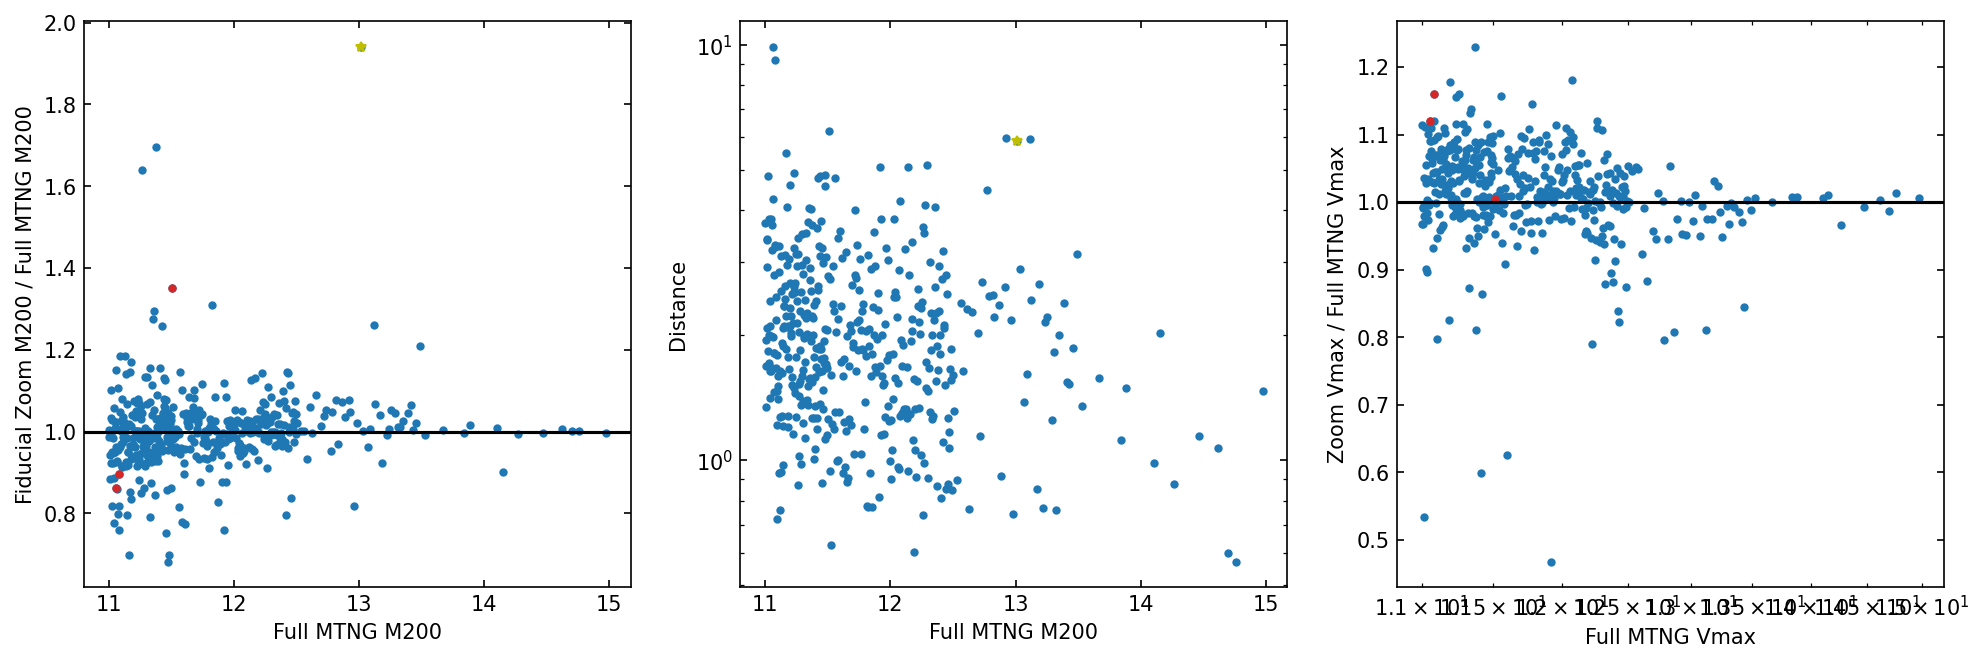

In [579]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(metr > 6)

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][final_sel])
Yarr = (zoom.fof['halo_m200b'][xmatch] / mtng.fof['halo_m200b'][final_sel])

Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][final_sel][w])
Yarr_out = (zoom.fof['halo_m200b'][xmatch][w] / mtng.fof['halo_m200b'][final_sel][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=3, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=3, ls='')

ax[0].plot(Xarr[ihalo], Yarr[ihalo], marker='*', color='y', ms=5, ls='')

ax[0].axhline(1, color='k')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200 / Full MTNG M200')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel]), metr, marker='o', color='C0', ms=3, ls='')
ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel][ihalo]), metr[ihalo], marker='*', color='y', ms=5, ls='')

#ax[1].set_xlim(8,14)
#ax[1].axhline(20, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax / Full MTNG Vmax')

ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][xmatch]], marker='o', color='C0', ms=3, ls='')
ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel][w]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel][w]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][xmatch][w]], marker='o', color='C3', ms=3, ls='')

ax[2].axhline(1, color='k')

Text(0, 0.5, 'N')

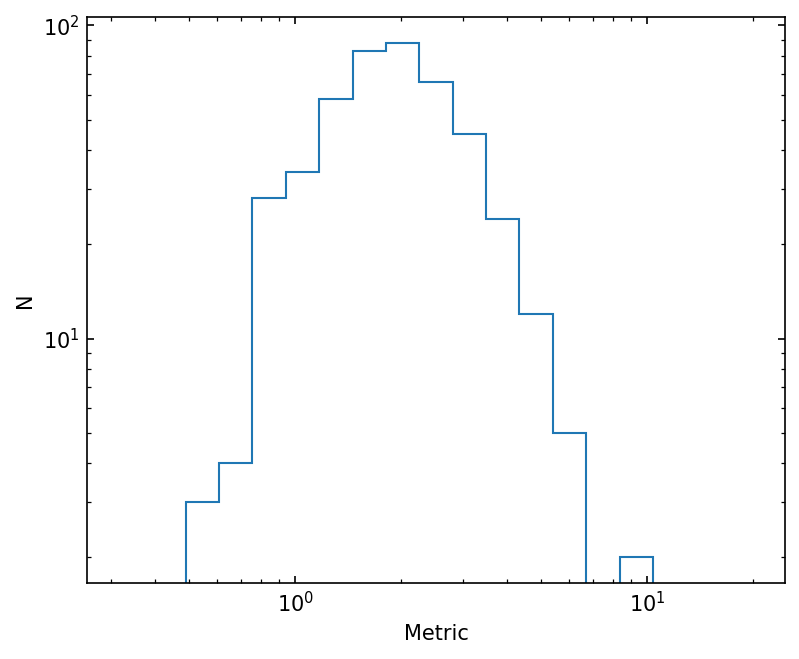

In [571]:
fig, ax = plt.subplots(dpi=150, figsize=(6,5))

ax.set_xscale('log')
ax.hist(metr, bins=np.logspace(-0.5,1.3,20), log=True, histtype='step')

ax.set_xlabel('Metric')
ax.set_ylabel('N')

### Let's work in a specific region

We will focus on one of the zoom halos

In [572]:
Pzoom = zoom.fof['halo_pos'][xmatch]
Pmtng = mtng.fof['halo_pos'][final_sel]

In [573]:
center = Pmtng[ihalo]

In [574]:
L_p = 5
z_slab = 5
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>0))[0]

In [575]:
zoom_grid = {}

part = ['dm', 'gas', 'stars']

for type in range(len(part)):
    zoom_sel = np.where( (getattr(zoom,part[type])['pos'][:,0]>(center[0]-L_p/2)) & (getattr(zoom,part[type])['pos'][:,0]<(center[0]+L_p/2)) &\
                        (getattr(zoom,part[type])['pos'][:,1]>(center[1]-L_p/2)) & (getattr(zoom,part[type])['pos'][:,1]<(center[1]+L_p/2)) &\
                        (getattr(zoom,part[type])['pos'][:,2]>(center[2]-z_slab/2)) & (getattr(zoom,part[type])['pos'][:,2]<(center[2]+z_slab/2)) )[0]

    zoom_grid[part[type]] = bacco.statistics.compute_mesh(pos=getattr(zoom, part[type])['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

In [576]:
sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

/tmp/ipykernel_401760/379568341.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
/tmp/ipykernel_401760/379568341.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])


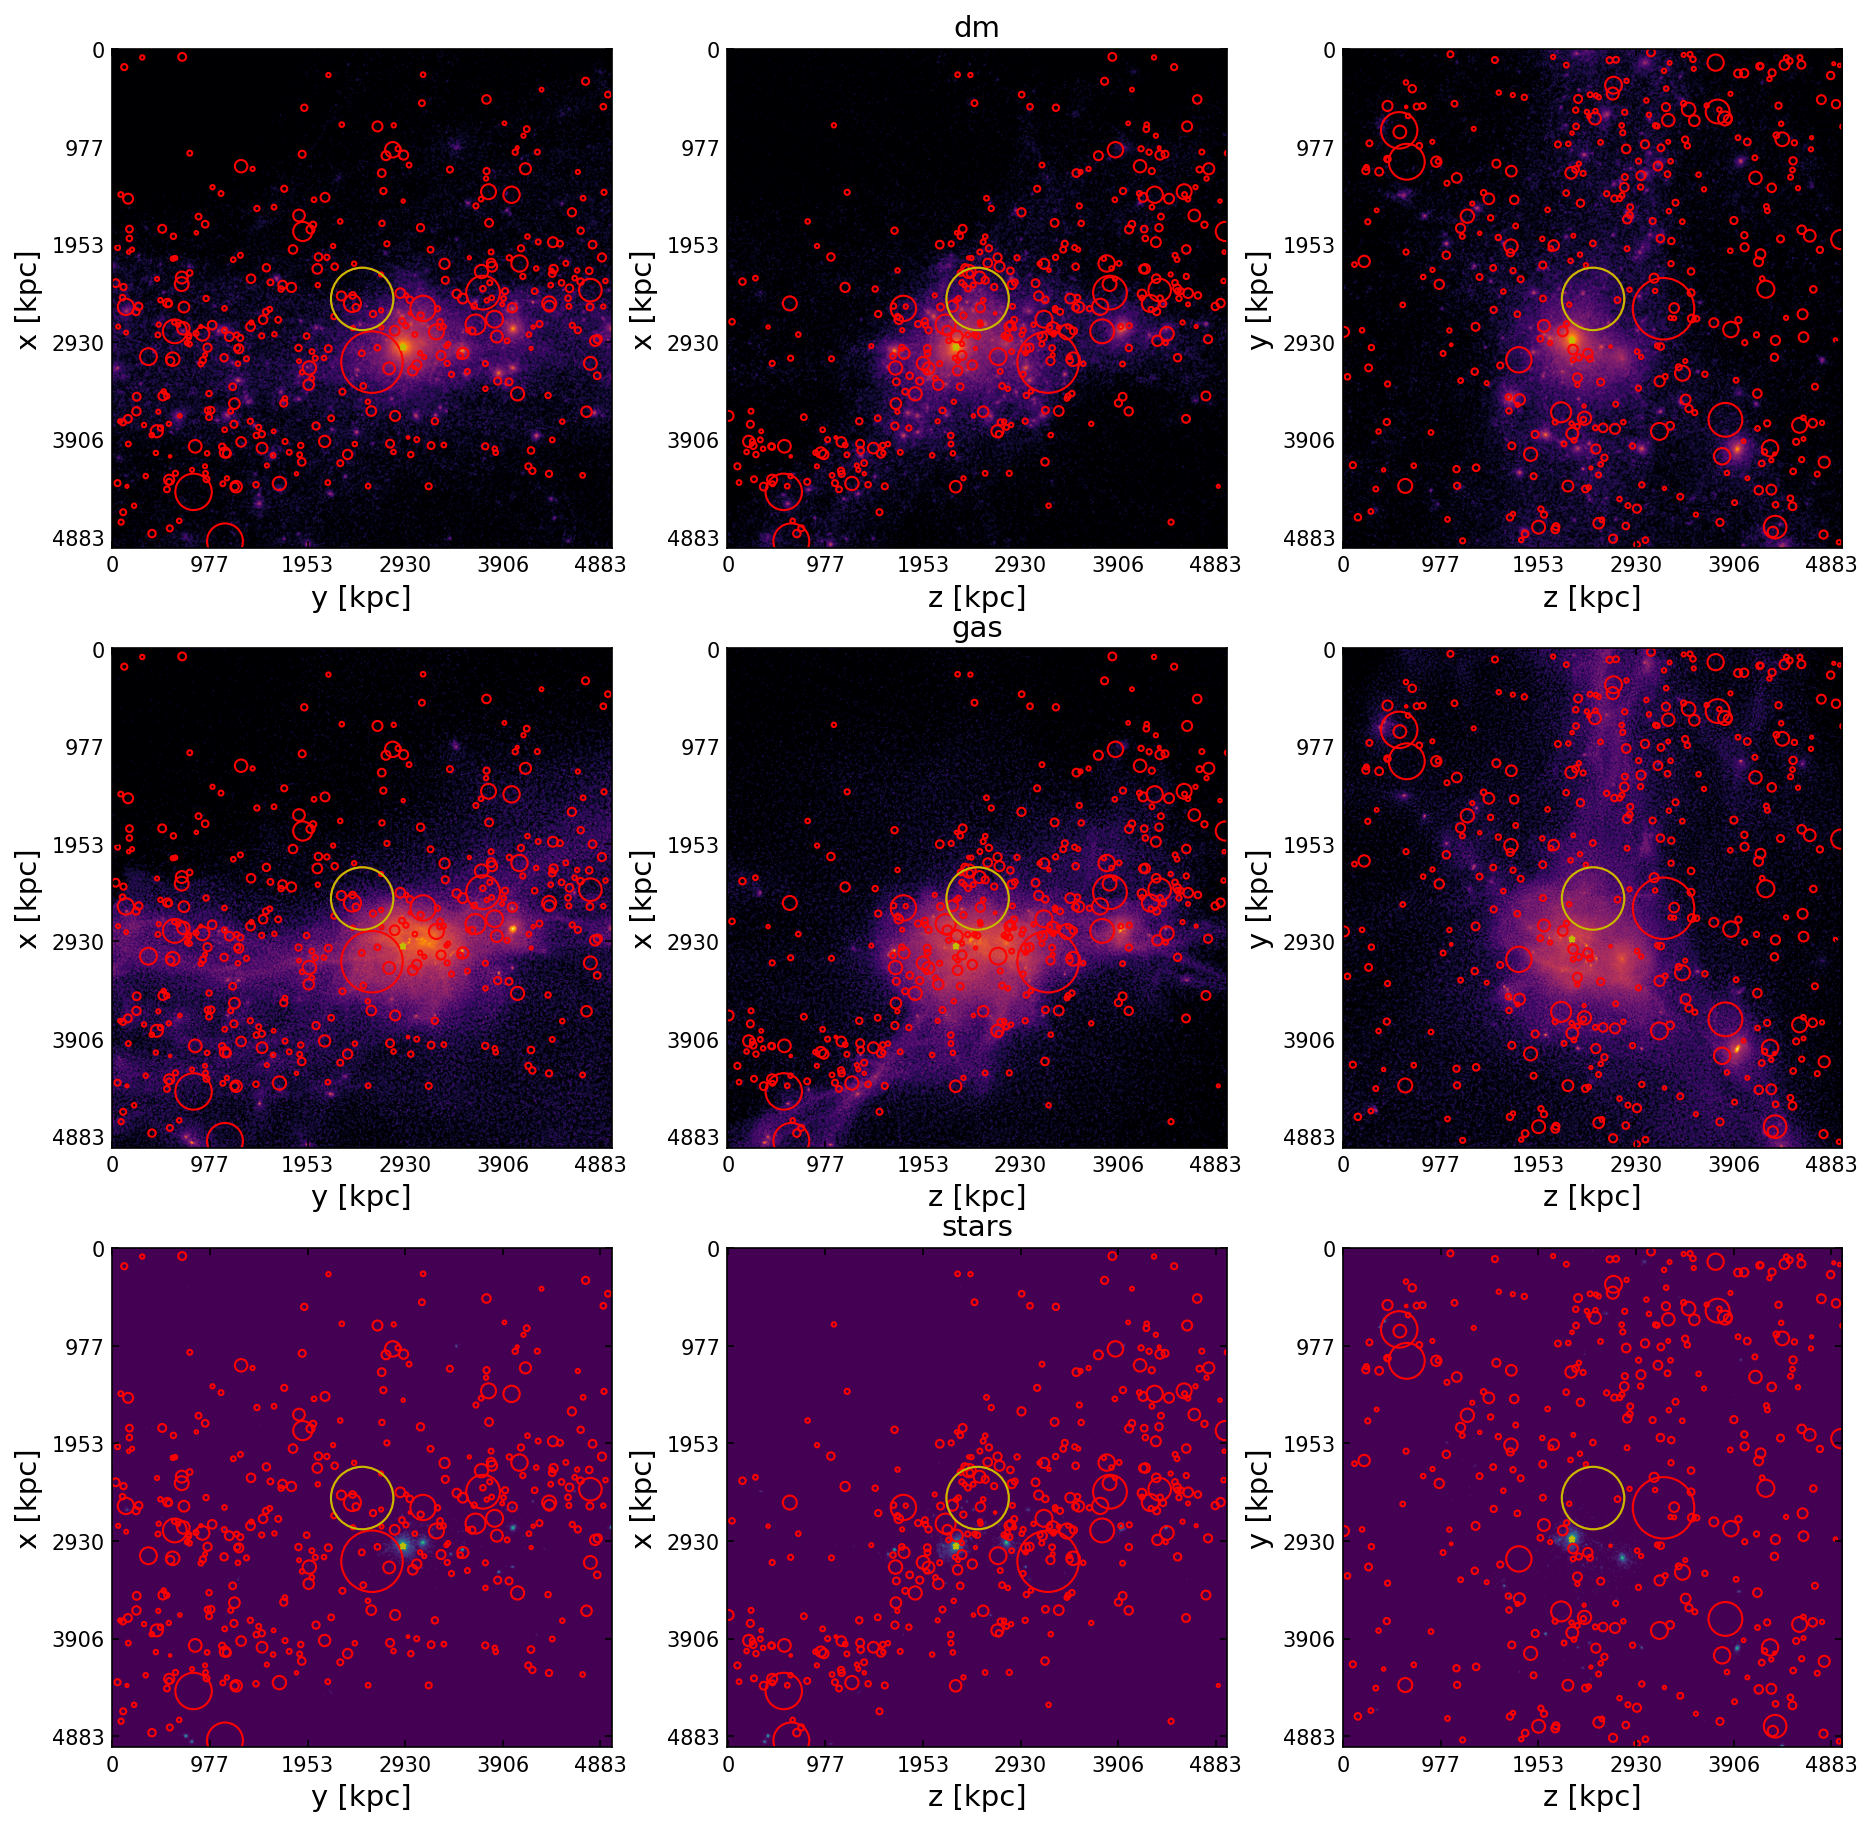

In [577]:
Pmtng_norm = (Pmtng-xmin[np.newaxis, :])/L_p * 512
Pzoom_norm = (Pzoom-xmin[np.newaxis, :])/L_p * 512

fig, ax = plt.subplots(3, 3, dpi=150, figsize=(15,15))

cmap = ['inferno', 'inferno', 'viridis']

for type in range(len(part)):
    ax[type, 0].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=2)), cmap=cmap[type])
    ax[type, 1].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=1)), cmap=cmap[type])
    ax[type, 2].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=0)), cmap=cmap[type])

    for i in range(3):
        xticklabels = 1000 * ax[type, i].get_xticks() / 512 * L_p
        yticklabels = 1000 * ax[type, i].get_yticks() / 512 * L_p
        ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
        ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])

    ax[type, 0].set_xlabel('y [kpc]', fontsize=14)
    ax[type, 0].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 1].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 1].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 2].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 2].set_ylabel('y [kpc]', fontsize=14)

    ax[type, 1].set_title(part[type], fontsize=14)

    for i in range(sel_pos.shape[0]):
        circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 0].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 1].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 2].add_artist(circle)

    ax[type, 0].plot( Pzoom_norm[ihalo][1], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 1].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 2].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][1], 'y*', ms=3)

    circle = plt.Circle((Pmtng_norm[ihalo][1], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 0].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 1].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][1]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 2].add_artist(circle)

plt.savefig('../images/zoom_snap{:d}_{:d}_fid.pdf'.format(snap, ihalo), bbox_inches='tight')

### Save the cross-match

In [578]:
np.save("/lscratch/fgmaion/MTNG-resims/cross-match/xmatch_fid.npy", [{'xmatch':xmatch, 'dmatch':dmatch}])